# 02 - Análisis Exploratorio de Datos (EDA)

Este notebook trabaja exclusivamente sobre `data/processed/dataset.csv`, generado por `01_build_dataset.ipynb`.

**Objetivos:**
1. Comparar los esquemas de etiquetado **multiclase** y **binario** (balance de clases, muestras descartadas).
2. Explorar la distribución de longitud de los tweets.
3. Analizar las palabras más frecuentes por clase.
4. Decidir y justificar, con base en estos resultados, qué esquema de etiqueta se usará para el entrenamiento.

## 1. Configuración e importación de librerías

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

sns.set_theme(style="whitegrid")
PROCESSED_DIR = "../data/processed"


## 2. Cargar el dataset procesado

In [34]:
df = pd.read_csv(f"{PROCESSED_DIR}/dataset.csv")
print(f"Filas: {len(df)} | Columnas: {list(df.columns)}")
df.head()


Filas: 149823 | Columnas: ['id', 'text', 'label_multiclass', 'label_multiclass_name', 'label_binary', 'split']


,id,text,label_multiclass,label_multiclass_name,label_binary,split
0,1114679353714016256,@FriskDontMiss Nigga,NaN,NaN,1,train
1,1063020048816660480,My horses are retarded,5.0,OtherHate,1,train
2,1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL S...,0.0,NotHate,0,train
3,1114558534635618305,I ran into this HOLY NIGGA TODAY 😭😭😭😭,0.0,NotHate,0,train
4,1035252480215592966,“EVERYbody calling you Nigger now!”,1.0,Racist,1,val


## 3. Valores nulos y vacíos remanentes

In [35]:
print("Valores nulos por columna:")
print(df.isna().sum())

n_empty_after_clean = (df["text"].str.strip() == "").sum()
print(f"\nTweets con texto vacio tras la limpieza: {n_empty_after_clean}")


Valores nulos por columna:
id                           0
text                         0
label_multiclass         11714
label_multiclass_name    11714
label_binary                 0
split                        0
dtype: int64

Tweets con texto vacio tras la limpieza: 0


## 4. Comparación de esquemas de etiquetado: Multiclase vs. Binario

Esta es la comparación clave para decidir con qué esquema entrenar el modelo.

In [36]:
n_total = len(df)
n_descartadas_multiclass = df["label_multiclass"].isna().sum()
pct_descartadas = n_descartadas_multiclass / n_total * 100

print("=== Esquema Multiclase (6 categorias) ===")
print(f"Muestras descartadas por empate: {n_descartadas_multiclass} ({pct_descartadas:.2f}%)")
print(f"Muestras utilizables: {n_total - n_descartadas_multiclass}")
print("\nDistribucion de clases (multiclase):")
print(df["label_multiclass_name"].value_counts(dropna=True))

print("\n=== Esquema Binario (Hate / NotHate) ===")
print(f"Muestras descartadas: 0 (0.00%)")
print(f"Muestras utilizables: {n_total}")
print("\nDistribucion de clases (binario):")
print(df["label_binary"].map({0: "NotHate", 1: "Hate"}).value_counts())


=== Esquema Multiclase (6 categorias) ===
Muestras descartadas por empate: 11714 (7.82%)
Muestras utilizables: 138109

Distribucion de clases (multiclase):
label_multiclass_name
NotHate      112844
Racist        11926
OtherHate      5811
Homophobe      3870
Sexist         3495
Religion        163
Name: count, dtype: int64

=== Esquema Binario (Hate / NotHate) ===
Muestras descartadas: 0 (0.00%)
Muestras utilizables: 149823

Distribucion de clases (binario):
label_binary
NotHate    112852
Hate        36971
Name: count, dtype: int64


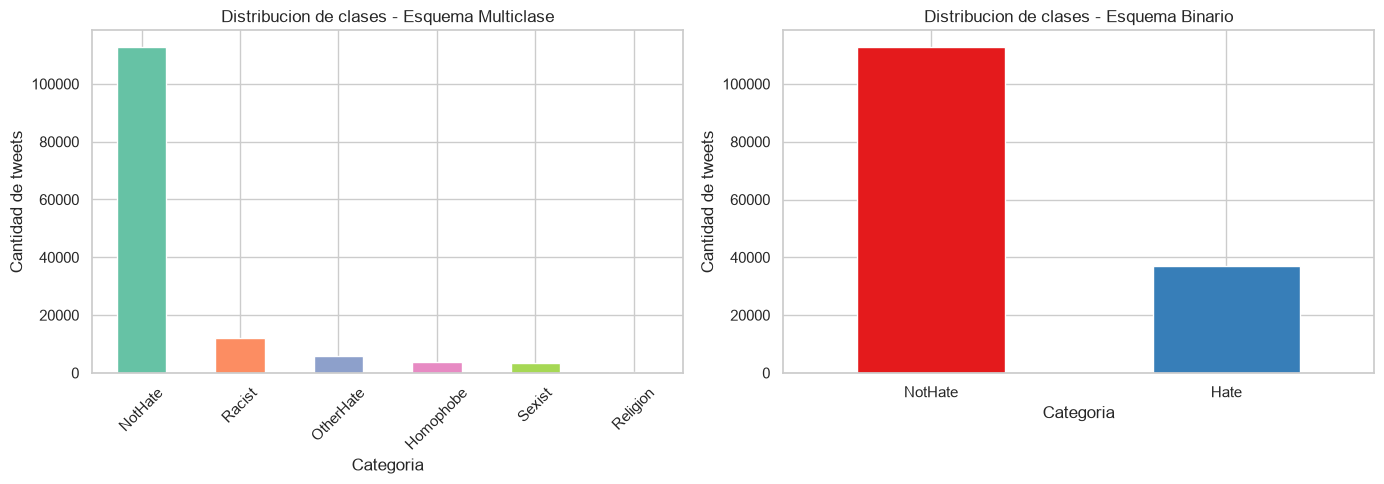

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["label_multiclass_name"].value_counts(dropna=True).plot(
    kind="bar", ax=axes[0], color=sns.color_palette("Set2")
)
axes[0].set_title("Distribucion de clases - Esquema Multiclase")
axes[0].set_xlabel("Categoria")
axes[0].set_ylabel("Cantidad de tweets")
axes[0].tick_params(axis="x", rotation=45)

df["label_binary"].map({0: "NotHate", 1: "Hate"}).value_counts().plot(
    kind="bar", ax=axes[1], color=sns.color_palette("Set1")
)
axes[1].set_title("Distribucion de clases - Esquema Binario")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Cantidad de tweets")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Nota de interpretación:** presta atención al grado de desbalance en cada esquema.
- Si en el esquema multiclase alguna categoría (ej. `Homophobe`, `Religion`) representa un porcentaje muy bajo del total, entrenar con 6 clases puede producir un modelo con muy mal desempeño en esas categorías minoritarias.
- El esquema binario, al agrupar todas las categorías de odio en una sola clase `Hate`, generalmente estará menos desbalanceado y es más robusto de entrenar en un plazo corto.

## 5. Distribución por split (train / val / test)

In [38]:
print(df["split"].value_counts())
print("\nProporcion de Hate/NotHate por split:")
print(df.groupby("split")["label_binary"].value_counts(normalize=True))


split
train    134823
test      10000
val        5000
Name: count, dtype: int64

Proporcion de Hate/NotHate por split:
split  label_binary
test   1               0.50010
       0               0.49990
train  0               0.78141
       1               0.21859
val    0               0.50020
       1               0.49980
Name: proportion, dtype: float64


## 6. Longitud de los tweets

In [39]:
df["text_len_chars"] = df["text"].str.len()
df["text_len_words"] = df["text"].str.split().str.len()

print(df[["text_len_chars", "text_len_words"]].describe())


       text_len_chars  text_len_words
count   149823.000000   149823.000000
mean        58.902899       10.434786
std         27.002321        5.131754
min          4.000000        1.000000
25%         37.000000        6.000000
50%         57.000000       10.000000
75%         80.000000       14.000000
max        135.000000       37.000000


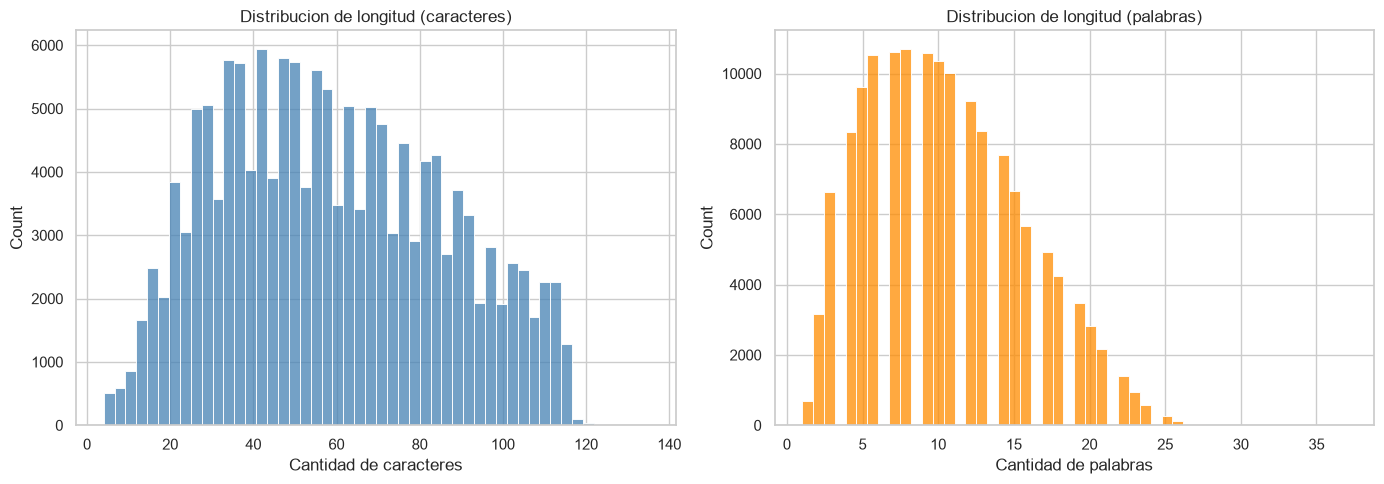

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["text_len_chars"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Distribucion de longitud (caracteres)")
axes[0].set_xlabel("Cantidad de caracteres")

sns.histplot(df["text_len_words"], bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Distribucion de longitud (palabras)")
axes[1].set_xlabel("Cantidad de palabras")

plt.tight_layout()
plt.show()


**Nota de interpretación:** esto responde a la advertencia inicial sobre si el texto del tweet (sin usar la imagen) es lo suficientemente informativo. Si la mayoría de los tweets tienen muy pocas palabras (ej. menos de 3-4), es una señal de que el modelo basado solo en texto podría tener limitaciones — vale la pena reportarlo explícitamente en el README.

## 7. Palabras más frecuentes por clase (Hate vs NotHate)

In [41]:
STOPWORDS_BASICAS = set([
    "the", "a", "an", "and", "or", "is", "are", "was", "were", "to", "of",
    "in", "on", "for", "with", "this", "that", "it", "i", "you", "he",
    "she", "we", "they", "at", "as", "be", "by", "from", "my", "your",
])

def get_word_freq(texts, top_n=20):
    words = []
    for t in texts:
        tokens = re.findall(r"\b[a-zA-Z]+\b", t.lower())
        words.extend([w for w in tokens if w not in STOPWORDS_BASICAS and len(w) > 2])
    return Counter(words).most_common(top_n)

hate_texts = df[df["label_binary"] == 1]["text"]
nothate_texts = df[df["label_binary"] == 0]["text"]

print("Top 20 palabras - Hate:")
print(get_word_freq(hate_texts))

print("\nTop 20 palabras - NotHate:")
print(get_word_freq(nothate_texts))


Top 20 palabras - Hate:
[('nigga', 10645), ('cunt', 4723), ('faggot', 3898), ('nigger', 3155), ('retarded', 2904), ('like', 2502), ('dyke', 2393), ('twat', 2344), ('retard', 1987), ('white', 1790), ('when', 1726), ('just', 1699), ('what', 1625), ('her', 1580), ('trash', 1549), ('ass', 1465), ('fuck', 1375), ('all', 1368), ('but', 1353), ('fucking', 1280)]

Top 20 palabras - NotHate:
[('nigga', 70053), ('cunt', 10042), ('like', 8801), ('twat', 5990), ('just', 5255), ('what', 5094), ('when', 5036), ('ass', 4955), ('dyke', 4652), ('all', 4632), ('got', 4160), ('but', 4136), ('fuck', 3970), ('out', 3940), ('can', 3824), ('shit', 3631), ('her', 3555), ('get', 3549), ('his', 3474), ('not', 3352)]


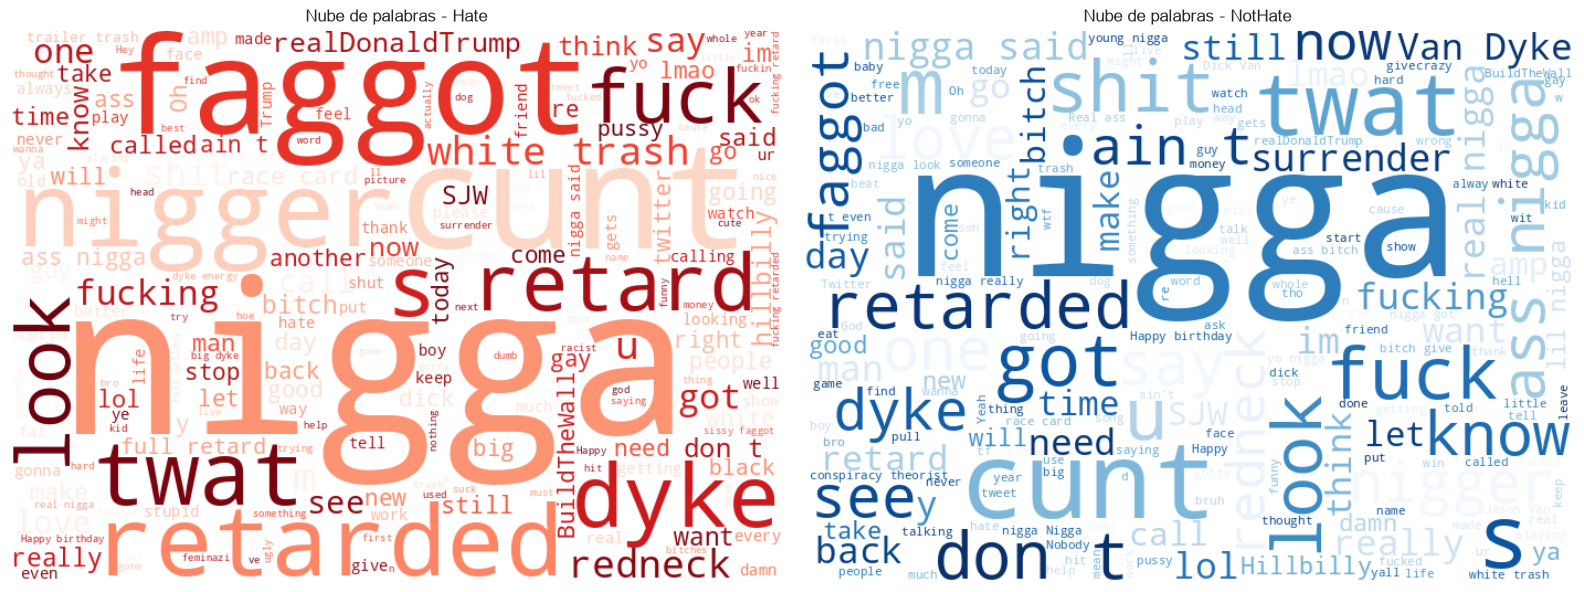

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_hate = WordCloud(width=700, height=500, background_color="white", colormap="Reds").generate(
    " ".join(hate_texts.astype(str))
)
axes[0].imshow(wc_hate, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Nube de palabras - Hate")

wc_nothate = WordCloud(width=700, height=500, background_color="white", colormap="Blues").generate(
    " ".join(nothate_texts.astype(str))
)
axes[1].imshow(wc_nothate, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Nube de palabras - NotHate")

plt.tight_layout()
plt.show()


## 8. Conclusión del EDA y decisión del esquema de etiquetado

**Resultados clave:**

- El dataset final contiene 149,823 tweets, divididos en splits oficiales `train` (134,823), `val` (5,000) y `test` (10,000), tras corregir un problema de splits duplicados detectado en la descarga inicial (ver nota en el README).
- **Esquema multiclase:** 7.82% de muestras descartadas por empate en la votación. Fuerte desbalance entre categorías, con `Religion` representando solo el 0.13% del dataset (163 muestras) — inviable para entrenar un clasificador de 6 clases en el plazo disponible.
- **Esquema binario:** 0% de muestras descartadas. Desbalance moderado (~75% NotHate / ~25% Hate), manejable con técnicas estándar (class weights).
- Los splits `val` y `test` están balanceados casi 50/50, mientras que `train` conserva la proporción natural del dataset — decisión de diseño de los autores para facilitar la interpretación de métricas en evaluación.
- La longitud promedio de los tweets (~10.4 palabras) confirma que el texto por sí solo contiene información suficiente para el modelado, sin depender del contenido visual del meme.
- Las palabras más frecuentes muestran que términos fuertes (ej. "nigga") aparecen con mucha más frecuencia en tweets etiquetados como `NotHate` que en `Hate`, evidenciando que el contexto es determinante y justificando el uso de un modelo contextual (DistilBERT) en lugar de un enfoque basado en palabras clave.

**Decisión final: se utilizará el esquema binario (Hate / NotHate) para el entrenamiento del modelo**, justificado por el desbalance severo e impracticable del esquema multiclase en categorías minoritarias. Esta decisión queda también documentada en la sección "Variable objetivo" del `README.md` principal.